In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = -2

In [3]:
def fx(x):
    return x**4 + x**3 - 2*x**2 - 2*x + 2

In [4]:
def df_dx(x):
    return 4*x**3 + 3*x**2 -4*x -2

In [5]:
x_plot = np.linspace(-2,2,500)

In [6]:
# Thể hiện sự thay đổi của hàm mục tiêu qua 4 epoch 
colors = ['r','c', 'b', 'g', 'y']

# Problem of SGD ( Gradient) with nonConvex function is function has local optimize point easily

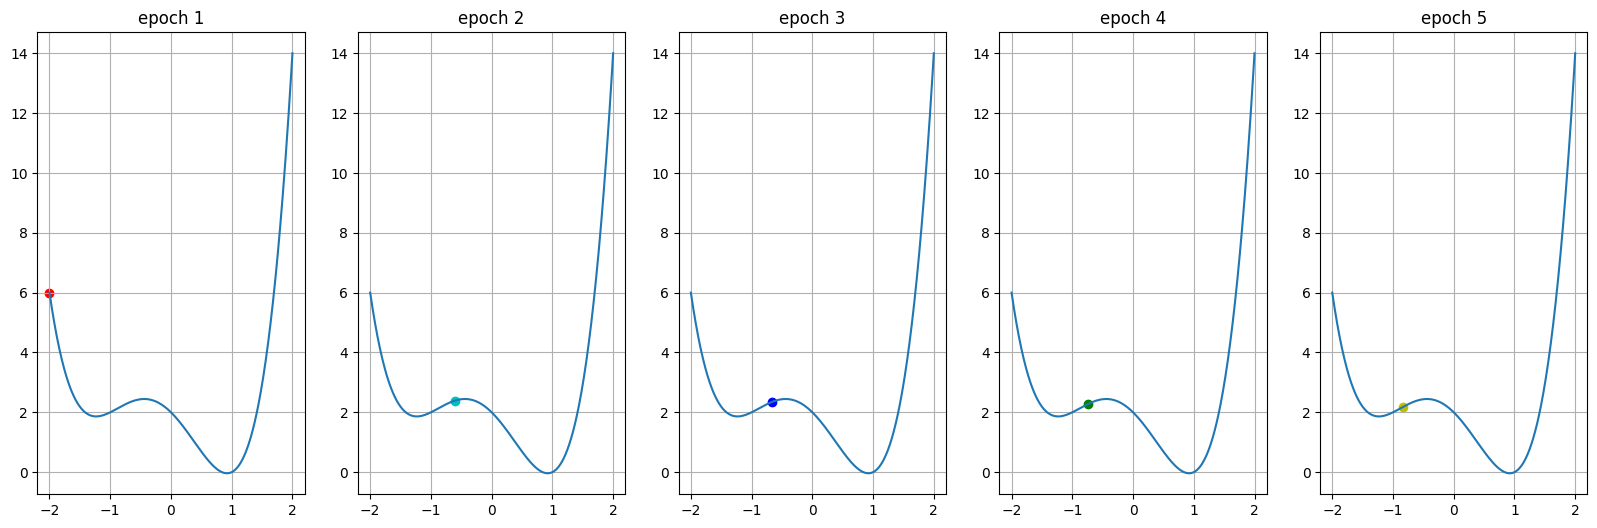

In [7]:
lr = 0.1
n_epochs = 5
fig, axs = plt.subplots(1,5, figsize = (20,6))
for i in range(n_epochs):
    axs[i].plot(x_plot,fx(x_plot))
    axs[i].scatter(x, fx(x),c = colors[i])
    axs[i].set_title(f"epoch {i+1}")
    axs[i].grid()
    x -=lr*df_dx(x)
fig.savefig("SGD_nonConvex.png", dpi = 300)

# Gradient with Momentum

In [8]:
x = -2

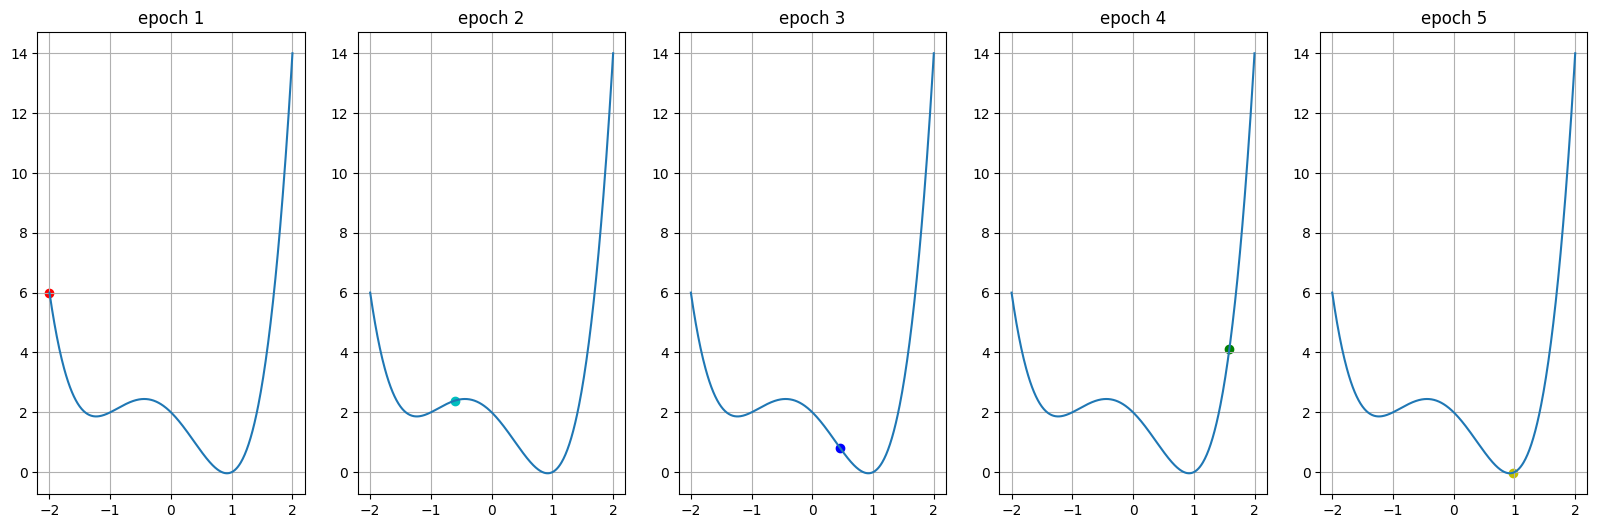

In [9]:
lr = 0.1
gama = 0.8
n_epochs = 5
fig, axs = plt.subplots(1,5, figsize = (20,6))
vt_1 = 0
for i in range(n_epochs):
    axs[i].plot(x_plot,fx(x_plot))
    axs[i].scatter(x, fx(x),c = colors[i])
    axs[i].set_title(f"epoch {i+1}")
    axs[i].grid()
    vt = gama*vt_1 + 0.1*df_dx(x)
    vt_1 = vt
    x -=vt

# Problem of Momentum Gradient Descent - Hiện tượng giao động quanh điểm tối ưu

In [10]:
def fx(x):
    #return x**2
    return x**4 + x**3 - 2*x**2 - 2*x + 2 

In [11]:
def derivative(x):
    #return 2*x
    return 4*x**3 + 3*x**2 -4*x -2

In [12]:
x_plot = np.linspace(-2,2,500)
y_plot = fx(x_plot)

In [13]:
x = -2
n_epochs = 20
lr = 0.09
gama = 0.7
vt_1 = 0
x_solution = [x,]
for epoch in range(n_epochs):
    vt = gama*vt_1 + lr*derivative(x)
    vt_1 = vt
    x -=vt
    print(f"epoch [{epoch+1}/{n_epochs}] - x = {x} - Loss = {fx(x)}")
    x_solution.append(x)

epoch [1/20] - x = -0.74 - Loss = 2.27944176
epoch [2/20] - x = 0.053628639999999894 - Loss = 1.8871531671306192
epoch [3/20] - x = 0.8076429444746209 - Loss = 0.032433448854652935
epoch [4/20] - x = 1.4404334595017136 - Loss = 2.263113765747401
epoch [5/20] - x = 0.9458084970192631 - Loss = -0.03442157177604077
epoch [6/20] - x = 0.5739450386714338 - Loss = 0.4908618752834828
epoch [7/20] - x = 0.5432559813486937 - Loss = 0.5706634383482878
epoch [8/20] - x = 0.7599428530994738 - Loss = 0.0974864239897062
epoch [9/20] - x = 1.0512788286602972 - Loss = 0.07036656399184515
epoch [10/20] - x = 1.0970042958760218 - Loss = 0.16752564609511733
epoch [11/20] - x = 0.9037548290729753 - Loss = -0.035775093867284724
epoch [12/20] - x = 0.78756483968002 - Loss = 0.05756771011241013
epoch [13/20] - x = 0.8264276996385062 - Loss = 0.012080399097092576
epoch [14/20] - x = 0.9435434244341516 - Loss = -0.035034734823780056
epoch [15/20] - x = 1.002421582124485 - Loss = 0.002462701580285831
epoch [16/

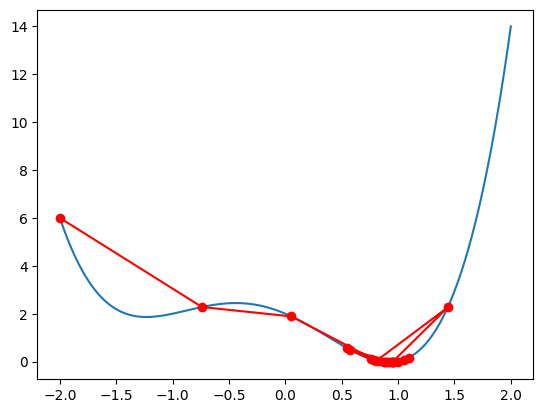

In [14]:
plt.plot(x_plot, y_plot)
plt.plot(x_solution,fx(np.array(x_solution)),'r-o')

# Solution: Nesterov Accelerate Gradient - (NAG)

In [15]:
def NAG(vt_1, gama, lr, x):
    vt = gama*vt_1 + lr*derivative(x - gama*vt_1)
    x -=vt
    return vt, x

In [16]:
x = -2
n_epochs = 20
lr = 0.09
gama = 0.7
vt_1 = 0
x_solution = [x,]
for epoch in range(n_epochs):
    vt_1, x = NAG(vt_1, gama, lr, x)
    print(f"epoch [{epoch+1}/{n_epochs}] - x = {x} - Loss = {fx(x)}")
    x_solution.append(x)

epoch [1/20] - x = -0.74 - Loss = 2.27944176
epoch [2/20] - x = 0.36664493631999995 - Loss = 1.0652116650648087
epoch [3/20] - x = 0.8452950962984496 - Loss = -0.005110067549604302
epoch [4/20] - x = 0.8170867807026583 - Loss = 0.02180802587002484
epoch [5/20] - x = 0.9102423281043207 - Loss = -0.036913324366793177
epoch [6/20] - x = 0.9155744428751371 - Loss = -0.03748982004339574
epoch [7/20] - x = 0.9223789990680233 - Loss = -0.037747901900783365
epoch [8/20] - x = 0.9219161084289232 - Loss = -0.03774748233609726
epoch [9/20] - x = 0.9222600594260084 - Loss = -0.03774803419542572
epoch [10/20] - x = 0.9222090896467235 - Loss = -0.03774804004848331
epoch [11/20] - x = 0.9222276947276661 - Loss = -0.03774804144645927
epoch [12/20] - x = 0.9222238921944544 - Loss = -0.03774804149112221
epoch [13/20] - x = 0.922224994340177 - Loss = -0.03774804149564659
epoch [14/20] - x = 0.922224737923059 - Loss = -0.03774804149586686
epoch [15/20] - x = 0.9222248061910214 - Loss = -0.0377480414958837

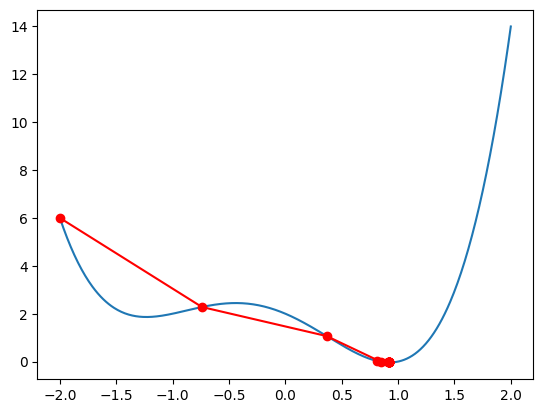

In [17]:
plt.plot(x_plot, y_plot)
plt.plot(x_solution,fx(np.array(x_solution)),'r-o')

In [18]:
import torch

In [20]:
optimizer = torch.optim.SGD(lr=0.01, momentum=0.8, nesterov=True)

TypeError: SGD.__init__() missing 1 required positional argument: 'params'